# Comprehensive EV Population Analysis and Machine Learning

## Introduction
This project analyzes electric vehicle population data to understand adoption trends, vehicle characteristics, manufacturer dominance, and geographic distribution.

In addition to exploratory data analysis (EDA), machine learning models are used to solve two prediction tasks:

1. **Classification Task**  
   Predicting the type of electric vehicle (BEV or PHEV)

2. **Regression Task**  
   Predicting the electric range of a vehicle

## Models Used
- Logistic Regression
- Decision Tree
- Random Forest
- Linear Regression

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
file_path = "/content/EV_Population_WA_Data.csv"
df = pd.read_csv(file_path)

df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EB0J,Thurston,Olympia,WA,98512.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,35.0,104823078,POINT (-122.957046 46.991391),PUGET SOUND ENERGY INC,5.306701e+10
1,WA1AAAGE9M,Kitsap,Port Orchard,WA,98367.0,2021,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,222,0,35.0,156660507,POINT (-122.6530052 47.4739066),PUGET SOUND ENERGY INC,5.303509e+10
2,5YJ3E1EA2J,Yakima,Yakima,WA,98902.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,14.0,269374108,POINT (-120.530331 46.59534),PACIFICORP,5.307700e+10
3,5YJ3E1EA4N,Yakima,Yakima,WA,98902.0,2022,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,15.0,213383894,POINT (-120.530331 46.59534),PACIFICORP,5.307700e+10
4,7SAYGAEE2P,Snohomish,Bothell,WA,98012.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,229496046,POINT (-122.206146 47.839957),PUGET SOUND ENERGY INC,5.306105e+10


## Dataset Overview
In this section, the dataset is explored to understand its size, structure, columns, and missing values.

In [3]:
print(f"Dataset shape: {df.shape}")
print("\nColumns:\n")
print(df.columns.tolist())

Dataset shape: (200048, 17)

Columns:

['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Base MSRP', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200048 entries, 0 to 200047
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         200048 non-null  object 
 1   County                                             200044 non-null  object 
 2   City                                               200044 non-null  object 
 3   State                                              200048 non-null  object 
 4   Postal Code                                        200044 non-null  float64
 5   Model Year                                         200048 non-null  int64  
 6   Make                                               200048 non-null  object 
 7   Model                                              200048 non-null  object 
 8   Electric Vehicle Type                              200048 non-null  object

In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0
Legislative District,442
Vehicle Location,8
2020 Census Tract,4
County,4
City,4
Postal Code,4
Electric Utility,4


In [6]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
VIN (1-10),200048,11978,7SAYGDEE6P,1219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
County,200044,199,King,102837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,200044,763,Seattle,32602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,200048,45,WA,199606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Postal Code,200044.0,NaN,NaN,NaN,98176.178121,2424.207811,1731.0,98052.0,98125.0,98372.0,99577.0
Model Year,200048.0,NaN,NaN,NaN,2020.871261,2.994933,1997.0,2019.0,2022.0,2023.0,2025.0
Make,200048,42,TESLA,88083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,200048,151,MODEL Y,41986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Electric Vehicle Type,200048,2,Battery Electric Vehicle (BEV),156956,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Clean Alternative Fuel Vehicle (CAFV) Eligibility,200048,3,Eligibility unknown as battery range has not b...,109401,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning
The dataset is cleaned by:
- removing irrelevant identifier and location-detail columns
- handling missing values
- creating a filtered dataset for electric-range-based analysis

In [7]:
columns_to_drop = [
    "VIN (1-10)",
    "DOL Vehicle ID",
    "Vehicle Location",
    "2020 Census Tract",
    "Postal Code",
    "Legislative District"
]

df_clean = df.drop(columns=columns_to_drop).copy()
df_clean = df_clean.dropna().copy()

print(f"Shape after dropping columns and null values: {df_clean.shape}")

Shape after dropping columns and null values: (200044, 11)


In [8]:
df_range = df_clean[df_clean["Electric Range"] > 0].copy()

print(f"Shape after filtering Electric Range > 0: {df_range.shape}")

Shape after filtering Electric Range > 0: (90643, 11)


In [9]:
df_range.head()

,County,City,State,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Electric Utility
0,Thurston,Olympia,WA,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,PUGET SOUND ENERGY INC
1,Kitsap,Port Orchard,WA,2021,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,222,0,PUGET SOUND ENERGY INC
2,Yakima,Yakima,WA,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,PACIFICORP
5,Yakima,Yakima,WA,2014,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,72,0,PACIFICORP
6,Thurston,Olympia,WA,2012,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,265,59900,PUGET SOUND ENERGY INC


In [10]:
df_range.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
County,90643,155,King,44054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,90643,619,Seattle,15137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,90643,38,WA,90413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model Year,90643.0,NaN,NaN,NaN,2018.705052,3.194257,1997.0,2017.0,2019.0,2021.0,2025.0
Make,90643,35,TESLA,25581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,90643,98,MODEL 3,13885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Electric Vehicle Type,90643,2,Battery Electric Vehicle (BEV),47553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Clean Alternative Fuel Vehicle (CAFV) Eligibility,90643,2,Clean Alternative Fuel Vehicle Eligible,69619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Electric Range,90643.0,NaN,NaN,NaN,118.035965,98.882247,6.0,30.0,75.0,215.0,337.0
Base MSRP,90643.0,NaN,NaN,NaN,2090.646437,11573.565714,0.0,0.0,0.0,0.0,845000.0


## Exploratory Data Analysis (EDA)
The following analysis explores:
- EV adoption trends over time
- distribution of EV types
- leading manufacturers
- county-level EV concentration
- electric range patterns
- comparison between BEVs and PHEVs

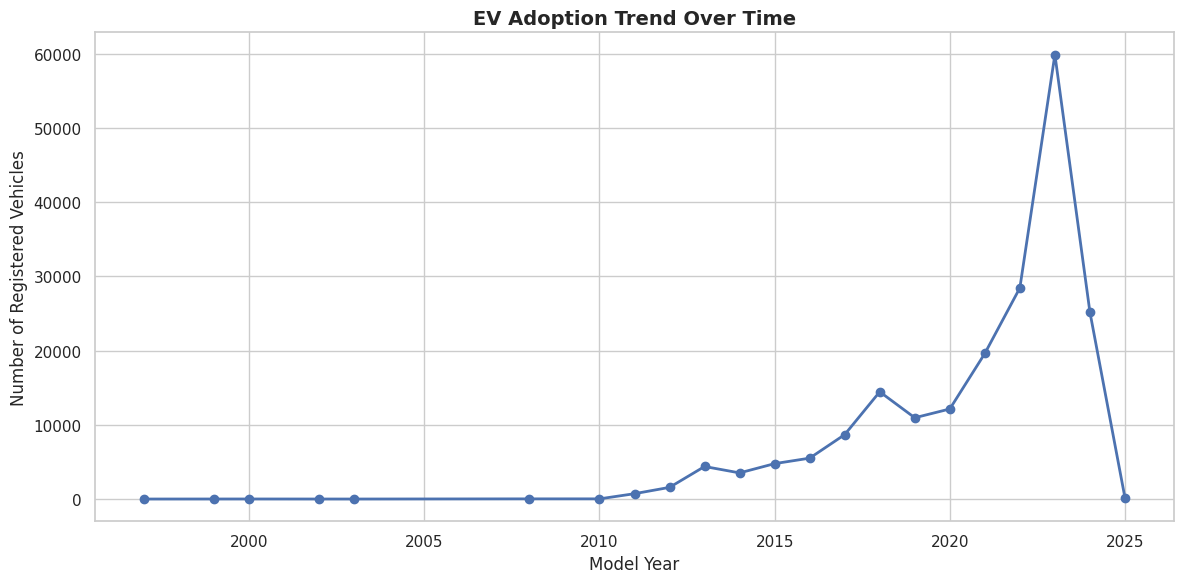

In [11]:
year_counts_all = df_clean["Model Year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(year_counts_all.index, year_counts_all.values, marker="o", linewidth=2)
plt.title("EV Adoption Trend Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Model Year")
plt.ylabel("Number of Registered Vehicles")
plt.tight_layout()
plt.show()

### Insight
EV registrations increase significantly over time, especially after 2015.  
The decline in the latest model year is likely due to incomplete or partial-year reporting rather than a true drop in adoption.

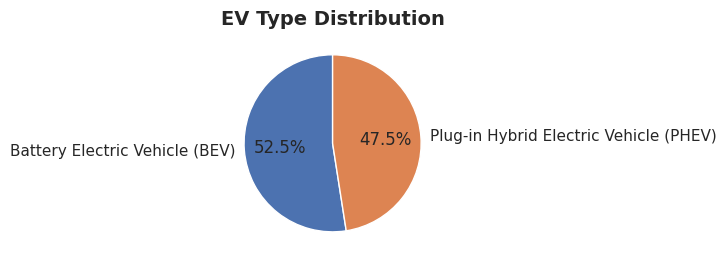

In [12]:
ev_type_counts = df_range["Electric Vehicle Type"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    ev_type_counts.values,
    labels=ev_type_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)
plt.title("EV Type Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [13]:
ev_type_percent = (
    df_range["Electric Vehicle Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentage")
)

ev_type_percent

,Percentage
Electric Vehicle Type,
Battery Electric Vehicle (BEV),52.46
Plug-in Hybrid Electric Vehicle (PHEV),47.54


### Insight
Battery Electric Vehicles (BEVs) slightly outnumber Plug-in Hybrid Electric Vehicles (PHEVs) in the filtered dataset, showing a stronger presence of fully electric vehicles.

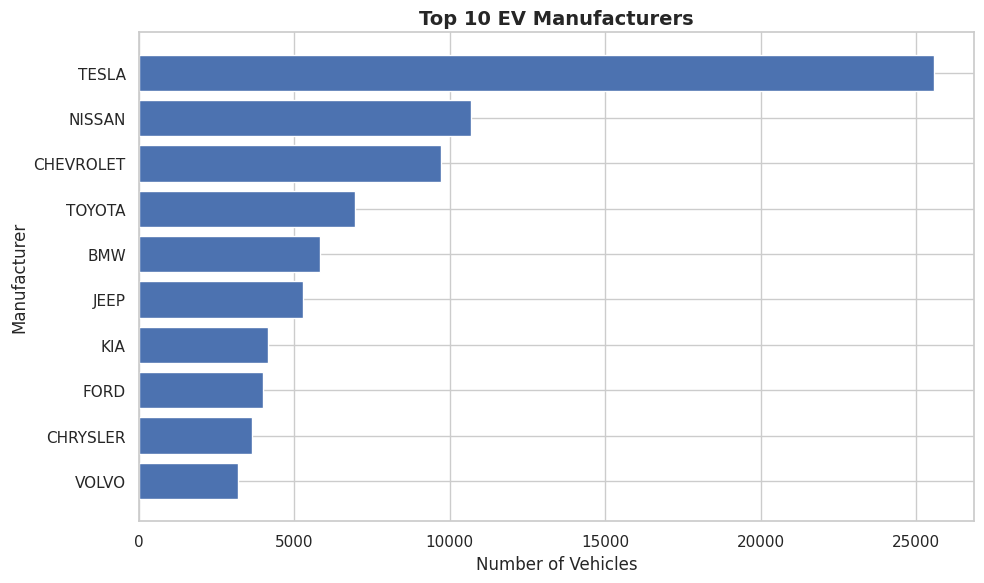

In [14]:
top_makes = df_range["Make"].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_makes.index, top_makes.values)
plt.title("Top 10 EV Manufacturers", fontsize=14, fontweight="bold")
plt.xlabel("Number of Vehicles")
plt.ylabel("Manufacturer")
plt.tight_layout()
plt.show()

In [15]:
df_range["Make"].value_counts().head(10).to_frame("Vehicle Count")

,Vehicle Count
Make,
TESLA,25581
NISSAN,10677
CHEVROLET,9706
TOYOTA,6937
BMW,5810
JEEP,5288
KIA,4139
FORD,3985
CHRYSLER,3620


### Insight
Tesla is the leading EV manufacturer in the dataset by a large margin, followed by Nissan and Chevrolet.

In [16]:
avg_range_by_make = (
    df_range.groupby("Make")["Electric Range"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

avg_range_by_make

,Electric Range
Make,
TESLA,240.79
JAGUAR,234.00
POLESTAR,233.00
CHEVROLET,141.46
VOLKSWAGEN,107.36
NISSAN,104.84
WHEEGO ELECTRIC CARS,100.00
TH!NK,100.00
FIAT,85.61


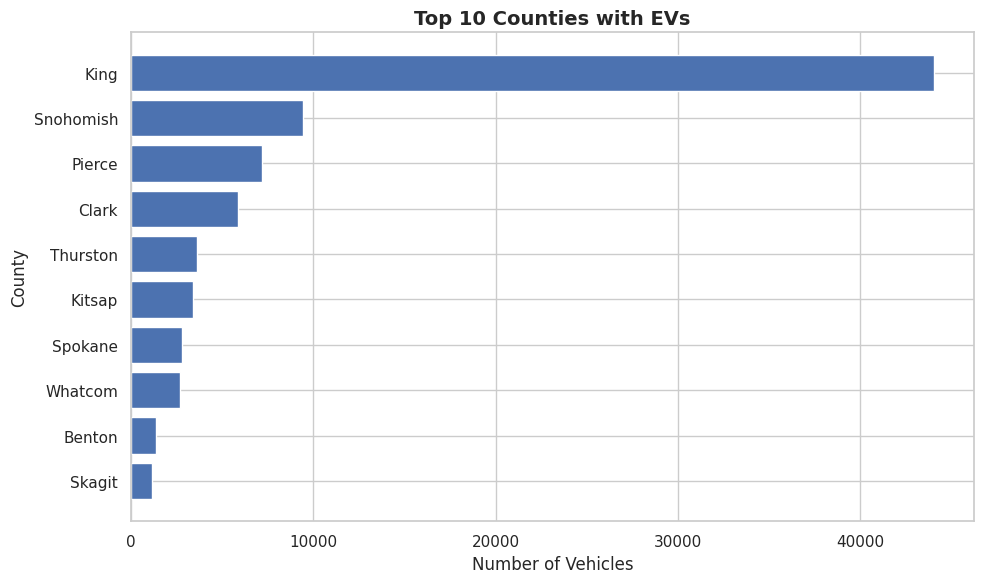

In [17]:
top_counties = df_range["County"].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_counties.index, top_counties.values)
plt.title("Top 10 Counties with EVs", fontsize=14, fontweight="bold")
plt.xlabel("Number of Vehicles")
plt.ylabel("County")
plt.tight_layout()
plt.show()

In [18]:
county_share = (
    df_range["County"]
    .value_counts(normalize=True)
    .head(10)
    .mul(100)
    .round(2)
    .to_frame("Percentage Share")
)

county_share

,Percentage Share
County,
King,48.60
Snohomish,10.38
Pierce,7.94
Clark,6.45
Thurston,3.97
Kitsap,3.72
Spokane,3.07
Whatcom,2.95
Benton,1.49


### Insight
King County has the highest concentration of EVs, indicating that EV adoption is heavily concentrated in urban and developed regions.

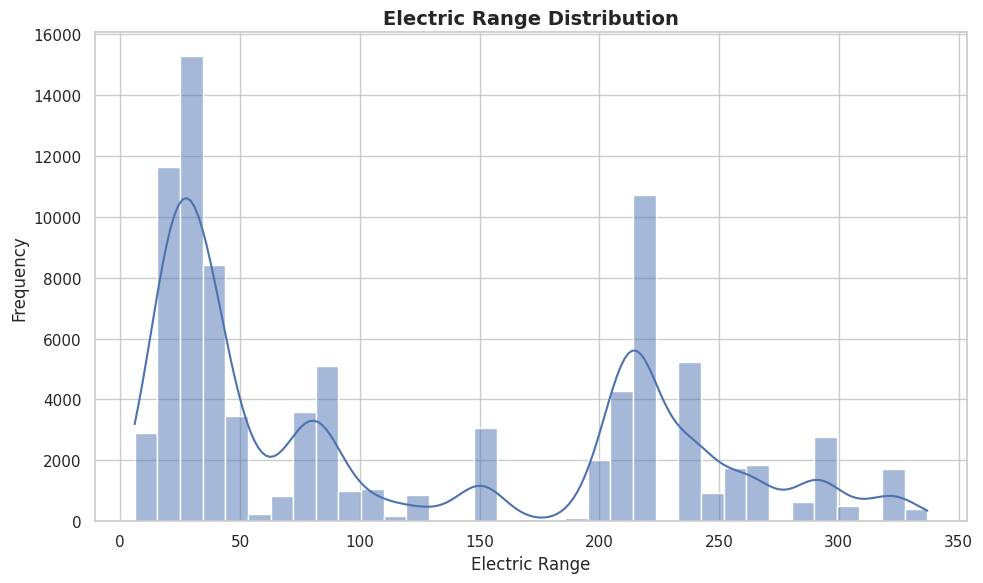

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df_range["Electric Range"], bins=35, kde=True)
plt.title("Electric Range Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Electric Range")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

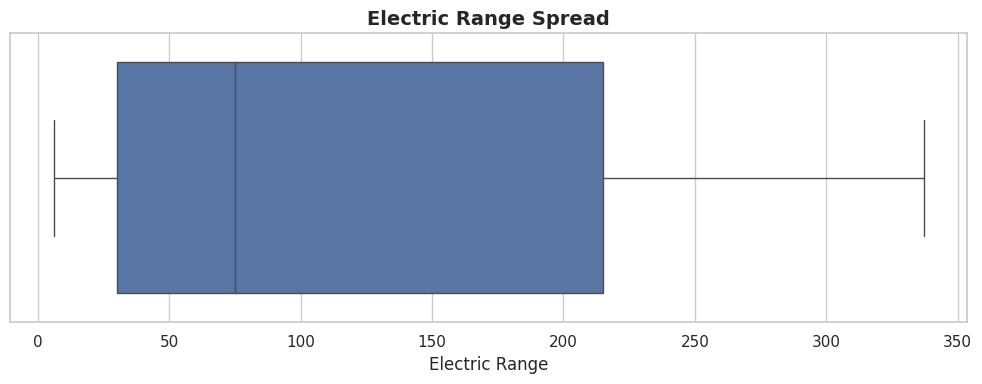

In [20]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_range["Electric Range"])
plt.title("Electric Range Spread", fontsize=14, fontweight="bold")
plt.xlabel("Electric Range")
plt.tight_layout()
plt.show()

### Insight
Electric range varies widely across vehicles, with many vehicles clustered in lower and medium ranges, while fewer vehicles offer very high electric range.

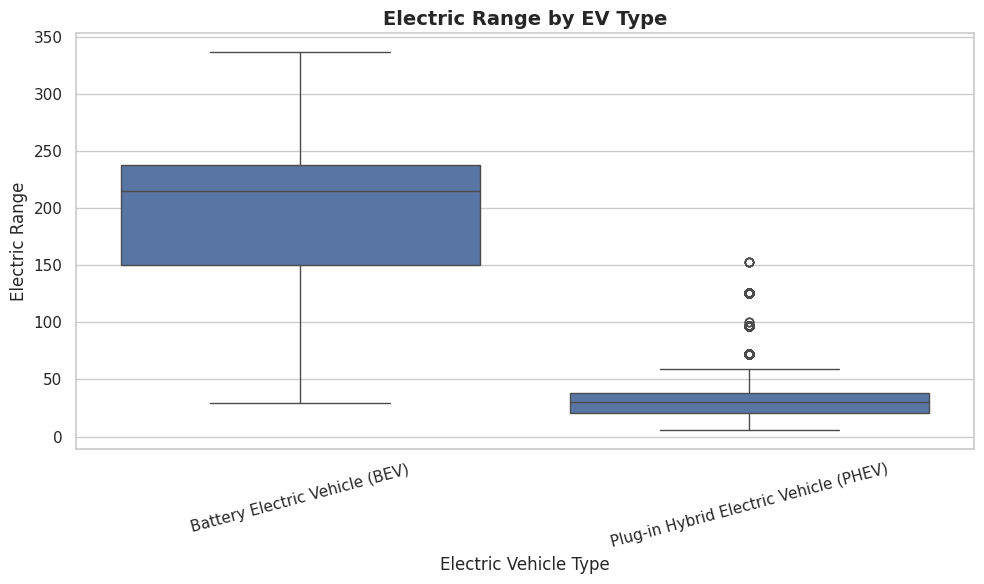

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_range,
    x="Electric Vehicle Type",
    y="Electric Range"
)
plt.title("Electric Range by EV Type", fontsize=14, fontweight="bold")
plt.xlabel("Electric Vehicle Type")
plt.ylabel("Electric Range")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [22]:
df_range.groupby("Electric Vehicle Type")["Electric Range"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Electric Vehicle Type,,,,,,,,
Battery Electric Vehicle (BEV),47553.0,196.95,73.01,29.0,150.0,215.0,238.0,337.0
Plug-in Hybrid Electric Vehicle (PHEV),43090.0,30.95,15.13,6.0,21.0,30.0,38.0,153.0


### Insight
BEVs have a much higher average electric range than PHEVs, which is expected because BEVs are fully electric while PHEVs rely partly on fuel.

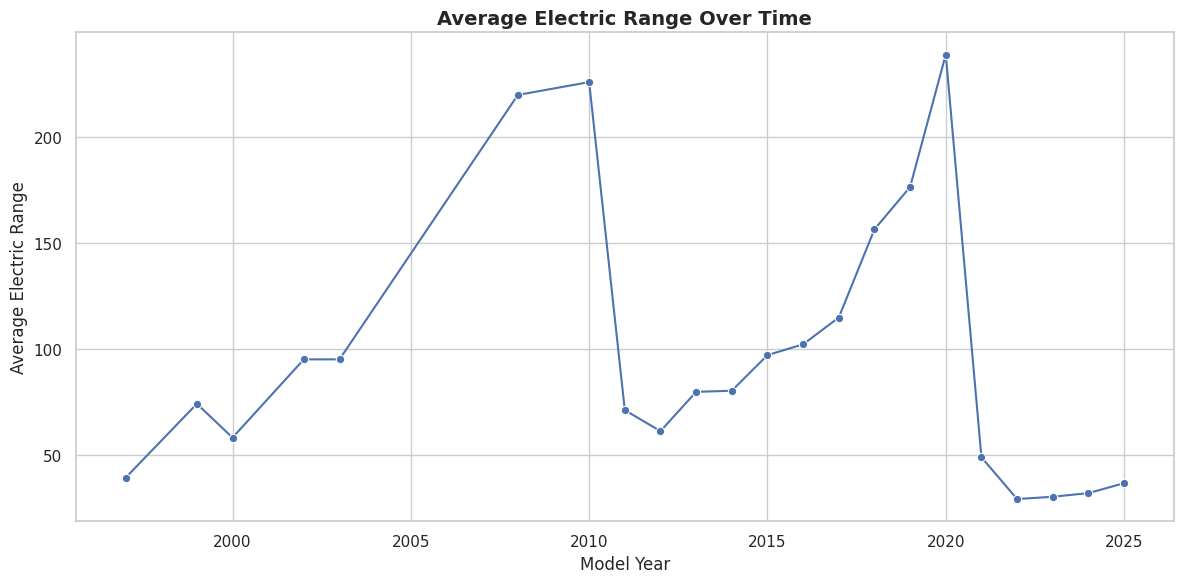

In [23]:
range_by_year = (
    df_range.groupby("Model Year")["Electric Range"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=range_by_year, x="Model Year", y="Electric Range", marker="o")
plt.title("Average Electric Range Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Model Year")
plt.ylabel("Average Electric Range")
plt.tight_layout()
plt.show()

### Insight
Average electric range generally improves over time, although some fluctuations appear because of variation in model mix and possible incomplete reporting for recent years.

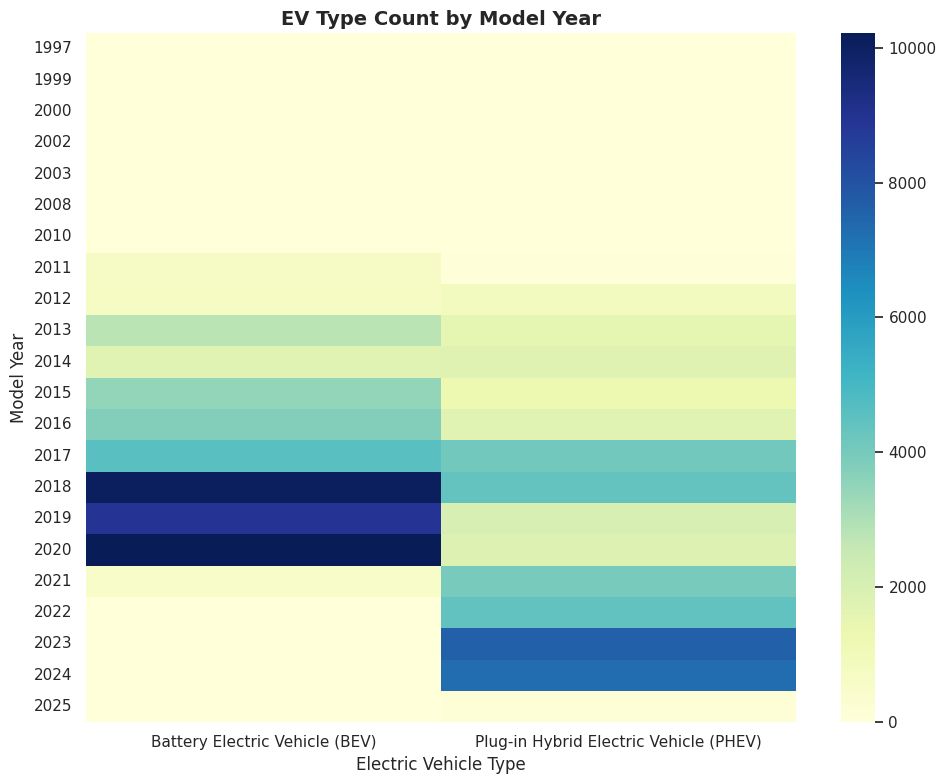

In [24]:
year_type_pivot = pd.crosstab(
    df_range["Model Year"],
    df_range["Electric Vehicle Type"]
)

plt.figure(figsize=(10, 8))
sns.heatmap(year_type_pivot, annot=False, cmap="YlGnBu")
plt.title("EV Type Count by Model Year", fontsize=14, fontweight="bold")
plt.xlabel("Electric Vehicle Type")
plt.ylabel("Model Year")
plt.tight_layout()
plt.show()

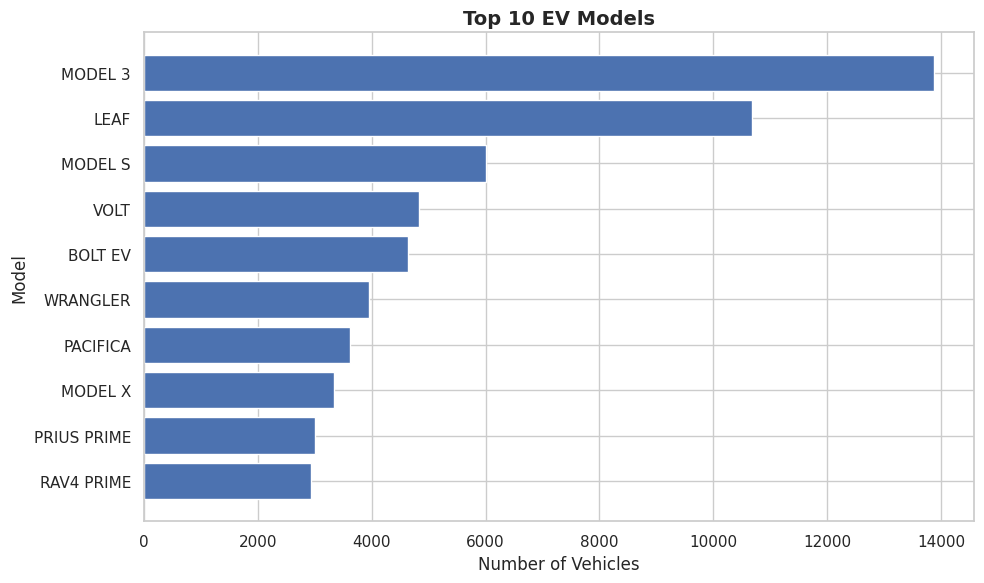

In [25]:
top_models = df_range["Model"].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_models.index, top_models.values)
plt.title("Top 10 EV Models", fontsize=14, fontweight="bold")
plt.xlabel("Number of Vehicles")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [26]:
print("Final cleaned dataset shape:", df_range.shape)
print("Number of unique manufacturers:", df_range["Make"].nunique())
print("Number of unique models:", df_range["Model"].nunique())
print("Number of unique counties:", df_range["County"].nunique())

Final cleaned dataset shape: (90643, 11)
Number of unique manufacturers: 35
Number of unique models: 98
Number of unique counties: 155


## Machine Learning Approach

In this project, multiple machine learning models are used for two different tasks:

### 1. Classification Task
Predicting the type of electric vehicle:
- Battery Electric Vehicle (BEV)
- Plug-in Hybrid Electric Vehicle (PHEV)

### 2. Regression Task
Predicting the electric range of a vehicle

### Model Justification
- Logistic Regression, Decision Tree, and Random Forest are used for classification because EV type is a categorical variable.
- Linear Regression is used for regression because electric range is a continuous numerical variable.

In [27]:
df_ml = df_range.copy()
df_ml.head()

,County,City,State,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Electric Utility
0,Thurston,Olympia,WA,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,PUGET SOUND ENERGY INC
1,Kitsap,Port Orchard,WA,2021,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,222,0,PUGET SOUND ENERGY INC
2,Yakima,Yakima,WA,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,PACIFICORP
5,Yakima,Yakima,WA,2014,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,72,0,PACIFICORP
6,Thurston,Olympia,WA,2012,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,265,59900,PUGET SOUND ENERGY INC


In [28]:
label_encoders = {}

categorical_columns = ["Make", "Model", "County", "City", "State", "Electric Utility",
                       "Clean Alternative Fuel Vehicle (CAFV) Eligibility", "Electric Vehicle Type"]

for col in categorical_columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le

df_ml.head()

,County,City,State,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Electric Utility
0,139,381,36,2018,29,51,0,0,215,0,68
1,64,424,36,2021,1,28,0,0,222,0,68
2,154,615,36,2018,29,51,0,0,215,0,60
5,154,615,36,2014,4,45,1,0,72,0,60
6,139,381,36,2012,29,52,0,0,265,59900,68


## Classification Models
The following models are used to predict the electric vehicle type:
- Logistic Regression
- Decision Tree
- Random Forest

In [46]:
X_class = df_ml[[
    "Model Year",
    "Make",
    "Model",
    "County",
    "City"
]]

y_class = df_ml["Electric Vehicle Type"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

In [47]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c, y_train_c)

y_pred_log = log_model.predict(X_test_c)

log_acc = accuracy_score(y_test_c, y_pred_log)

print("Logistic Regression Accuracy:", round(log_acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_test_c, y_pred_log))

Logistic Regression Accuracy: 0.8229

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.88      0.84      9496
           1       0.86      0.76      0.80      8633

    accuracy                           0.82     18129
   macro avg       0.83      0.82      0.82     18129
weighted avg       0.83      0.82      0.82     18129



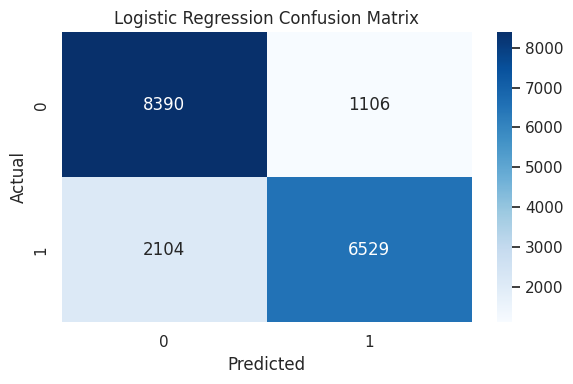

In [48]:
cm_log = confusion_matrix(y_test_c, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [49]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_c, y_train_c)

y_pred_dt = dt_model.predict(X_test_c)

dt_acc = accuracy_score(y_test_c, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_test_c, y_pred_dt))

Decision Tree Accuracy: 0.9882

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9496
           1       0.99      0.99      0.99      8633

    accuracy                           0.99     18129
   macro avg       0.99      0.99      0.99     18129
weighted avg       0.99      0.99      0.99     18129



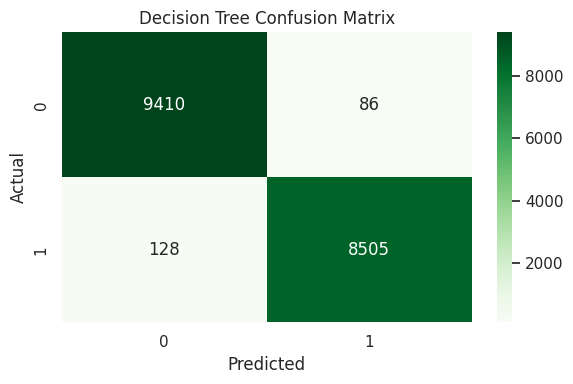

In [50]:
cm_dt = confusion_matrix(y_test_c, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [51]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_c, y_train_c)

y_pred_rf = rf_model.predict(X_test_c)

rf_acc = accuracy_score(y_test_c, y_pred_rf)

print("Random Forest Accuracy:", round(rf_acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_test_c, y_pred_rf))

Random Forest Accuracy: 0.9887

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9496
           1       0.99      0.99      0.99      8633

    accuracy                           0.99     18129
   macro avg       0.99      0.99      0.99     18129
weighted avg       0.99      0.99      0.99     18129



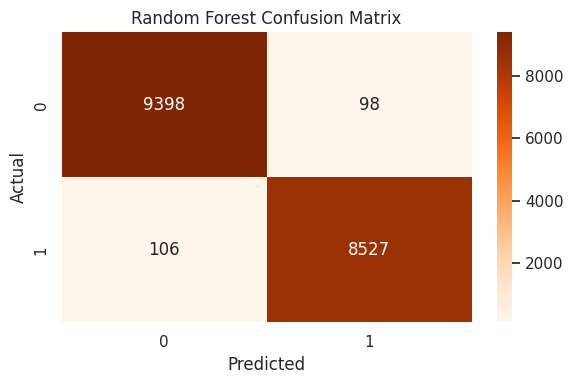

In [52]:
cm_rf = confusion_matrix(y_test_c, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [53]:
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [log_acc, dt_acc, rf_acc]
}).sort_values(by="Accuracy", ascending=False)

classification_results

,Model,Accuracy
2,Random Forest,0.988747
1,Decision Tree,0.988196
0,Logistic Regression,0.822936


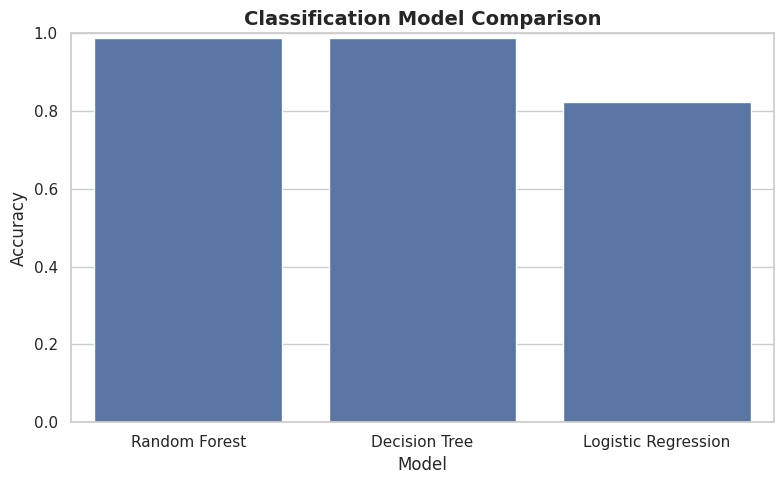

In [54]:
plt.figure(figsize=(8, 5))
sns.barplot(data=classification_results, x="Model", y="Accuracy")
plt.title("Classification Model Comparison", fontsize=14, fontweight="bold")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

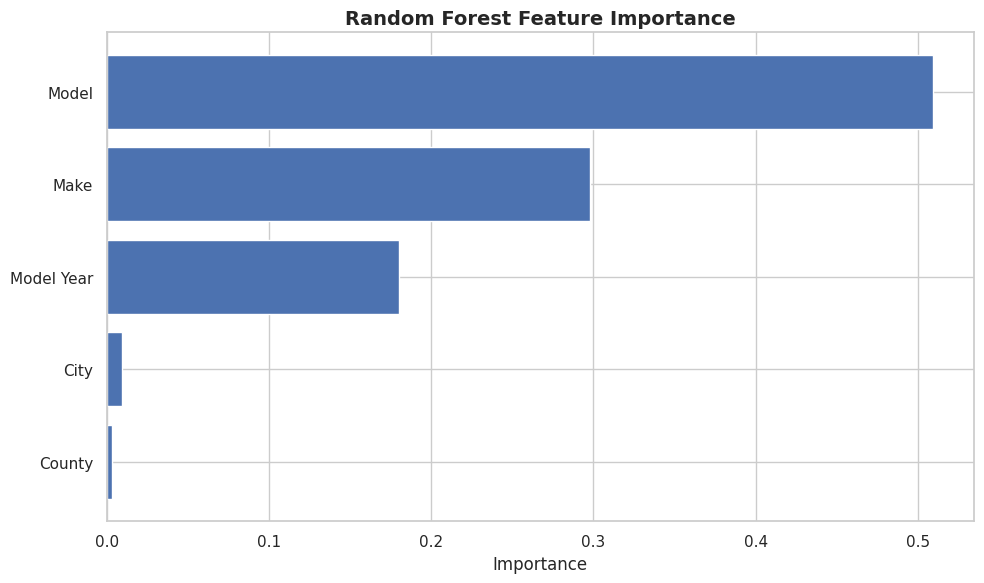

,Feature,Importance
2,Model,0.509136
1,Make,0.297736
0,Model Year,0.180233
4,City,0.009270
3,County,0.003625


In [55]:
feature_importance = pd.DataFrame({
    "Feature": X_class.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Random Forest Feature Importance", fontsize=14, fontweight="bold")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

feature_importance.sort_values(by="Importance", ascending=False)

### Classification Insight
The classification models are used to predict EV type. Comparing their accuracy helps determine which algorithm performs best for distinguishing between BEVs and PHEVs.

## Regression Model
A Linear Regression model is used to predict the electric range of a vehicle.

In [56]:
X_reg = df_ml[[
    "Model Year",
    "Make",
    "Model",
    "County",
    "City",
    "Base MSRP"
]]

y_reg = df_ml["Electric Range"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [57]:
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_r, y_train_r)

y_pred_lr = lin_reg_model.predict(X_test_r)

In [58]:
mae = mean_absolute_error(y_test_r, y_pred_lr)
mse = mean_squared_error(y_test_r, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_lr)

print("Linear Regression Performance:")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

Linear Regression Performance:
MAE  : 73.45
MSE  : 7233.84
RMSE : 85.05
R2   : 0.2650


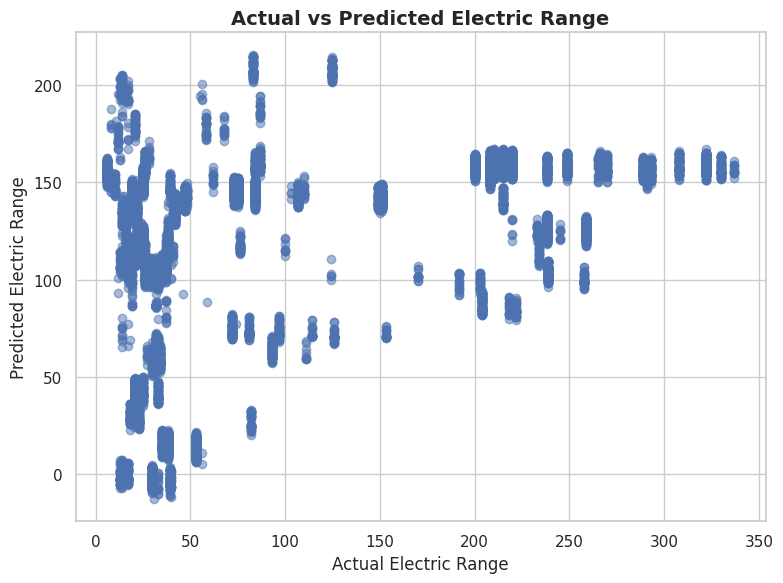

In [59]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_lr, alpha=0.5)
plt.title("Actual vs Predicted Electric Range", fontsize=14, fontweight="bold")
plt.xlabel("Actual Electric Range")
plt.ylabel("Predicted Electric Range")
plt.tight_layout()
plt.show()

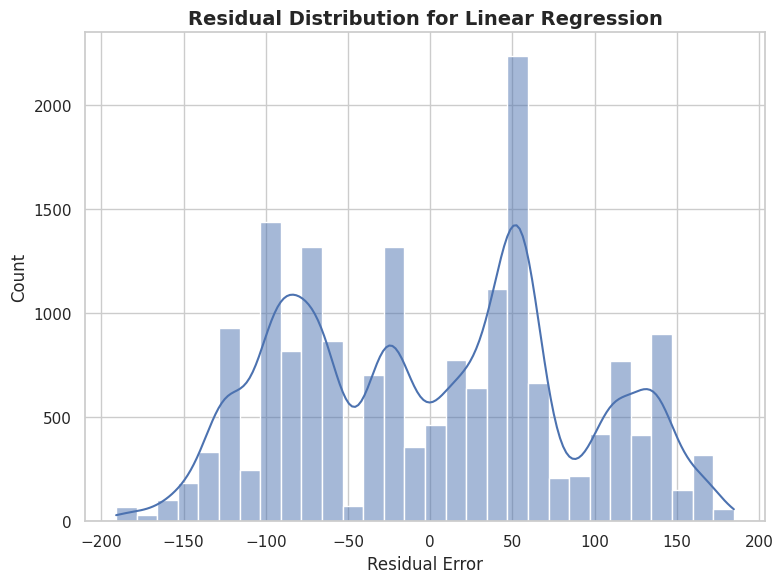

In [60]:
residuals = y_test_r - y_pred_lr

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution for Linear Regression", fontsize=14, fontweight="bold")
plt.xlabel("Residual Error")
plt.tight_layout()
plt.show()

In [61]:
coefficients = pd.DataFrame({
    "Feature": X_reg.columns,
    "Coefficient": lin_reg_model.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
1,Make,3.819974
5,Base MSRP,-0.000100
4,City,-0.017857
3,County,-0.032885
0,Model Year,-0.544498
2,Model,-1.507014


### Regression Insight
Linear Regression provides a baseline model for predicting electric range. Its performance helps evaluate how well the selected vehicle attributes explain electric range variation.

## Overall Conclusion

This project combined exploratory data analysis and machine learning to study electric vehicle population data.

The EDA showed that:
- EV registrations have increased strongly over time
- BEVs slightly outnumber PHEVs in the filtered dataset
- Tesla is the dominant manufacturer
- EV adoption is highly concentrated in counties such as King County
- BEVs generally offer much higher electric range than PHEVs

The machine learning section extended the analysis by using:
- Logistic Regression
- Decision Tree
- Random Forest  
for classification of EV type, and
- Linear Regression  
for prediction of electric range

Overall, the project demonstrates both analytical and predictive approaches for understanding electric vehicle trends and characteristics.

In [62]:
print("Project completed successfully.")
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Range-based dataset shape: {df_range.shape}")

Project completed successfully.
Original dataset shape: (200048, 17)
Cleaned dataset shape: (200044, 11)
Range-based dataset shape: (90643, 11)


## ✅ Final Summary

This project successfully combines exploratory data analysis and machine learning to understand electric vehicle trends.

Key achievements:
- Identified strong growth in EV adoption
- Compared BEV and PHEV characteristics
- Analyzed manufacturer and geographic distribution
- Built classification models to predict EV type
- Built a regression model to predict electric range

This project demonstrates practical data analysis, visualization, and machine learning skills.